## Image Processing for the "Laser-sheet first experiment"
### Jasmine JARDRI - UROP (Soft Matter Science & Engineering team, ESPCI-PSL)

#### Required libraries

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from scipy.optimize import curve_fit

#### Spatial calibration (using a picture of a ruler with the same camera settings as the ones used for the experiment)

In [ ]:
points = [] # variable to store the clicked points 

# Function called whenever the user clicks on the mouse : 
def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        points.append((x, y))
        cv2.circle(image, (x, y), 3, (0, 0, 255), -1)
        cv2.imshow("Image", image)
        if len(points) == 2: 
            (x1, y1), (x2, y2) = points

            # Distance between the two click points : 
            distance_pixels = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            distance_mm = 50 # replace by the real distance between two points you clicked on (50 is for two points separated by 5 cm on the ruler)
            pixel_to_mm = distance_mm / distance_pixels

            # Results : 
            print(f"Point 1 : ({x1}, {y1})")
            print(f"Point 2 : ({x2}, {y2})")
            print(f"Distance en pixels : {distance_pixels:.2f}")
            print(f"1 pixel = {pixel_to_mm:.4f} mm")


# Load and show the ruler spicture : 
image = cv2.imread("C:\\Users\\jajou\\OneDrive\\Documents\\echelle_partie2_exp1.jpg")
cv2.imshow("Image", image)

cv2.setMouseCallback("Image", click_event)
cv2.waitKey(0)
cv2.destroyAllWindows()

Point 1 : (71, 391)
Point 2 : (1252, 398)
Distance en pixels : 1181.02
1 pixel = 0.0423 mm


#### Profile extraction
This method is different from the pilot experiment : detection of the "center of mass" of light intensity

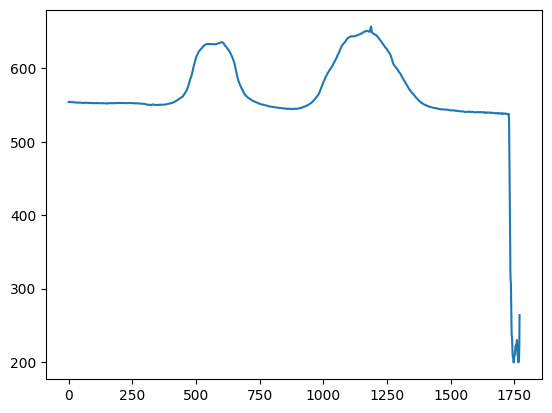

In [7]:
img = cv2.imread("C:\\Users\\jajou\\OneDrive\\Documents\\CPES\\CPES 2\\Stage_UROP\\Experiences\\Exp2026-06\\Exp2026-06-09\\Nappe_laser\\Exp2\\Img_exp2\\Img_exp_001.jpg", cv2.IMREAD_GRAYSCALE) # replace by the path of your image

# Slight image smoothing : 
img = cv2.GaussianBlur(img, (5,5), 0)

height, width = img.shape

y_profile = []

for x in range(width):

    col = img[:, x].astype(float)

    if col.max() < 20 :
        y_profile.append(np.nan)
        continue

    y = np.arange(height)

    # Center of mass of light intensity : 
    yc = np.sum(y * col) / np.sum(col)

    y_profile.append(yc)

y_profile = np.array(y_profile)

plt.plot(y_profile)
plt.show()

#### List of amplitudes for a stack of images
Here again, the method is different since the sinusoidal fit is onl used to determine a typical wavelength for the stack, but the amplitude is simply expressed as h = max(y) - min(y) in "peak" area

 
Characteristic time tau : 32.49 min
Offset : 0.70 mm


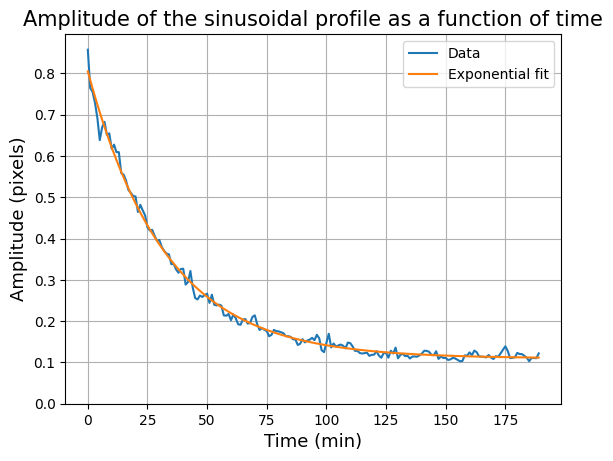

In [ ]:
def extract_interface_laser(path) : 
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Unread image :", path)
        return None
    img = cv2.GaussianBlur(img, (5,5), 0)

    height, width = img.shape

    y_profile = []

    for x in range(width):

        col = img[:, x].astype(float)

        if col.max() < 10:
            y_profile.append(np.nan)
            continue

        y = np.arange(height)
        sum_col = np.sum(col)
        if sum_col == 0 : 
            y_profile.append(np.nan) 
            continue

        yc = np.sum(y * col) / np.sum(col)

        y_profile.append(yc)

    y_profile = np.array(y_profile)
    return y_profile



def interface_STACK(basepath, prefixe, nb_images) :  # returns the list of interface positions for each image (i.e. interfaces[i] corresponds to the interface for the image n°i of the stack)
    interfaces=[]
    for i in range(1,nb_images+1): 
        filename=f"{prefixe}{i:03d}.jpg"   # Pad i with zeros on the left to make a 3-digit number
        path=base_path + "\\" + filename
        interface=extract_interface_laser(path)
        interfaces.append(interface)
    return interfaces


def Amplitude_STACK_laser(basepath,prefixe, nb_images, deb, fin, scale) : # returns the list of amplitude for a stack of images (i.e A[i] is a number corresponding to the amplitude of the profile of image n°i)
    A=[]
    interfaces = interface_STACK(basepath, prefixe, nb_images)
    cpt=0
    for i in range(nb_images):
        y_data = interfaces[i][deb:fin]
        x_data = np.arange(len(y_data))

        px_to_mm = scale

        x_data_mm = x_data * px_to_mm
        y_data_mm = y_data * px_to_mm
        ampl = np.nanmax(y_data_mm) - np.nanmin(y_data_mm)
        A.append(ampl)
    return A


def exp_model(x, B, tau, D): 
    return B*np.exp(-x/tau) + D


base_path="C:\\Users\\jajou\\OneDrive\\Documents\\CPES\\CPES 2\\Stage_UROP\\Experiences\\Exp2026-06\\Exp2026-06-11\\Nappe_laser\\Exp2\\Img_exp2" # replace by the path of your stack of images
prefixe="Img_exp_" # replace by the prefixe of the images of your stack (for instance here the name of the first image was : Img_exp_001)
nb_images=190   # replace by the number of images in your stack
begin = 450     # complete the "begin" and "end" variable with the borders of the image area with the peak (determined manually)
end = 570
px_to_mm = 0.0376  # replace by the value returned by the calibration script (cell above)
A=Amplitude_STACK_laser(base_path, prefixe, nb_images, deb = begin, fin = end, scale = px_to_mm)

y_data=np.array(A)
x_data = np.arange(len(A))

# Parameters to help the fit-function : 
B_0=A[0]
p0=[B_0, 1, 1]

# Exponential fit for the amplitude over time :  
popt, pcov = curve_fit(exp_model,x_data, y_data, p0)
B_fit, tau_fit, D_fit= popt

print(" ")
print(f"Characteristic time tau : {tau_fit:.2f} min") 
print(f"Offset : {B_fit:.2f} mm")


# Plot : 
fig, ax = plt.subplots()
ax.plot(x_data,y_data, label='Data')
ax.plot(x_data, exp_model(x_data, *popt), label=f"Exponential fit")
ax.set_title("Amplitude of the sinusoidal profile as a function of time", fontsize = 15)
ax.set_xlabel("Time (min)", fontsize = 13)
ax.set_ylabel("Amplitude (pixels)", fontsize = 13)
ax.grid()
ax.set_ylim(bottom=0)
ax.legend()
plt.show()